In [1]:
!pip install sentence-transformers -q

In [2]:
from sentence_transformers import SentenceTransformer
import numpy as np

sentences = [
    "The batsman hit a six off the last ball to win the match.",
    "India won the Test series after a brilliant bowling display.",
    "The spinner took five wickets on a turning pitch in Nagpur.",
    "Sauté the onions in olive oil until they turn golden brown.",
    "Add a pinch of salt and let the dough rest for thirty minutes.",
    "The recipe calls for fresh basil and ripe cherry tomatoes.",
    "Preheat the oven to 180 degrees before placing the cake inside.",
    "The hacker exploited a SQL injection vulnerability in the login form.",
    "Always use two-factor authentication to protect your accounts.",
    "Ransomware encrypted all files on the hospital network overnight."
]
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)
print("Shape:", embeddings.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Shape: (10, 384)


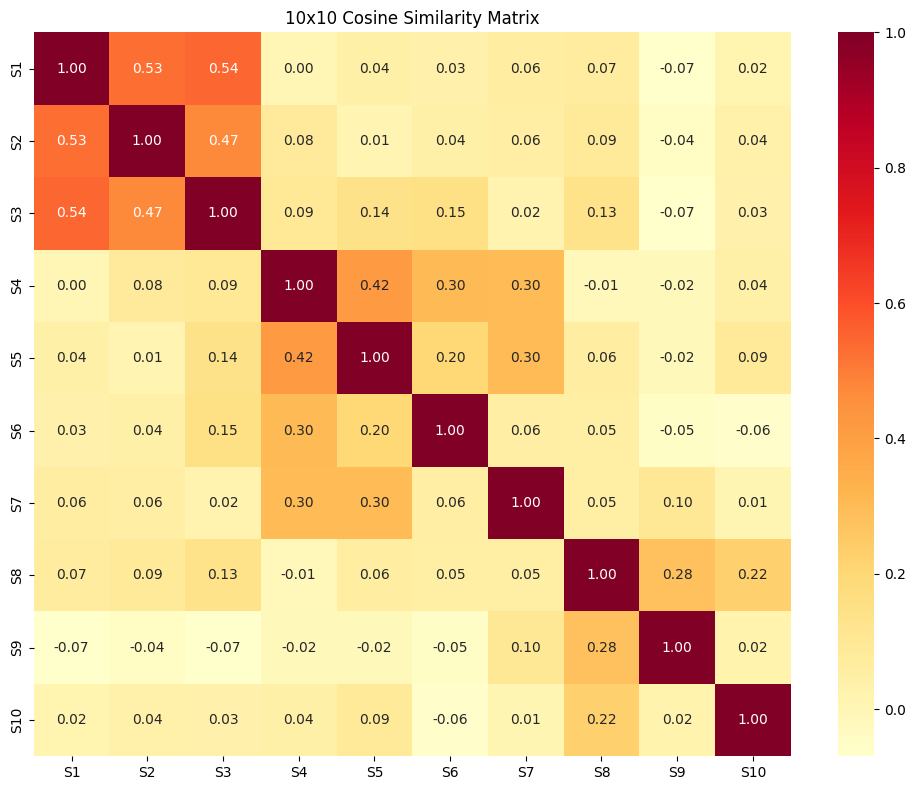

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

cos_sim = cosine_similarity(embeddings)
labels = [f"S{i+1}" for i in range(10)]
plt.figure(figsize=(10,8))
sns.heatmap(cos_sim, annot=True, fmt=".2f", xticklabels=labels, yticklabels=labels, cmap="YlOrRd")
plt.title("10x10 Cosine Similarity Matrix")
plt.tight_layout()
plt.show()


In [4]:
query = "The bowler took three wickets in one over"
query_emb = model.encode([query])
sims = cosine_similarity(query_emb, embeddings)[0]
top2 = np.argsort(sims)[::-1][:2]
print(f"Query: {query}\n")
for rank, idx in enumerate(top2, 1):
    print(f"Top {rank}: \"{sentences[idx]}\" | Score: {sims[idx]:.4f}")

Query: The bowler took three wickets in one over

Top 1: "The spinner took five wickets on a turning pitch in Nagpur." | Score: 0.6652
Top 2: "The batsman hit a six off the last ball to win the match." | Score: 0.6088
